# Bootstrap evaluation of Bayes Estimator vs smAP

In [1]:
import math
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
# PyTorch
import torch
import torchmetrics

/home/denny-loevlie/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import layers
import models
import utils

In [3]:
auroc = torchmetrics.AUROC(task="binary")
# Generate Bayes estimator predictions for bootstrap comparison
delta = 2.0
deltaS = 3
test_size = 1000

# Generate test data
X_test, lengths_test, u_test, y_test = utils.generate_toy_data(test_size, delta=delta, deltaS=deltaS, seed=2)

# Compute Bayes optimal predictions
bayes_proba = torch.stack([utils.proba_y1_given_h(X_i[:,0], delta, deltaS=deltaS) for X_i in torch.split(X_test, lengths_test)])

# Convert to numpy for bootstrap functions
y_true = y_test#.numpy()
y_pred_bayes = bayes_proba#.numpy()

print(f"Test set size: {len(y_true)}")
print(f"Bayes AUROC: {auroc(y_pred_bayes, y_true):.4f}")

Test set size: 1000
Bayes AUROC: 0.9396


In [4]:
# Loading smAP predictions
import pandas as pd
smAP_df = pd.read_csv("../instance_smMIL_test_preds.csv")
smAP_df.head()

,predicted_probability,ground_truth
0,0.158290,0.0
1,0.701464,0.0
2,0.792198,1.0
3,0.534015,1.0
4,0.985301,1.0


In [5]:
smAP_predictions = torch.tensor(smAP_df['predicted_probability'].values)
y_true = torch.tensor(smAP_df['ground_truth'].values)

In [15]:
# make sure y_true is the same as y_test
for i in range(len(y_true)):
    # print(f"y_true[{i}] = {y_true[i]}, y_test[{i}][0] = {y_test[i][0]}")
    assert y_true[i] == y_test[i][0]

print(f"All ground truth labels match between smAP and generated data.")

All ground truth labels match between smAP and generated data.


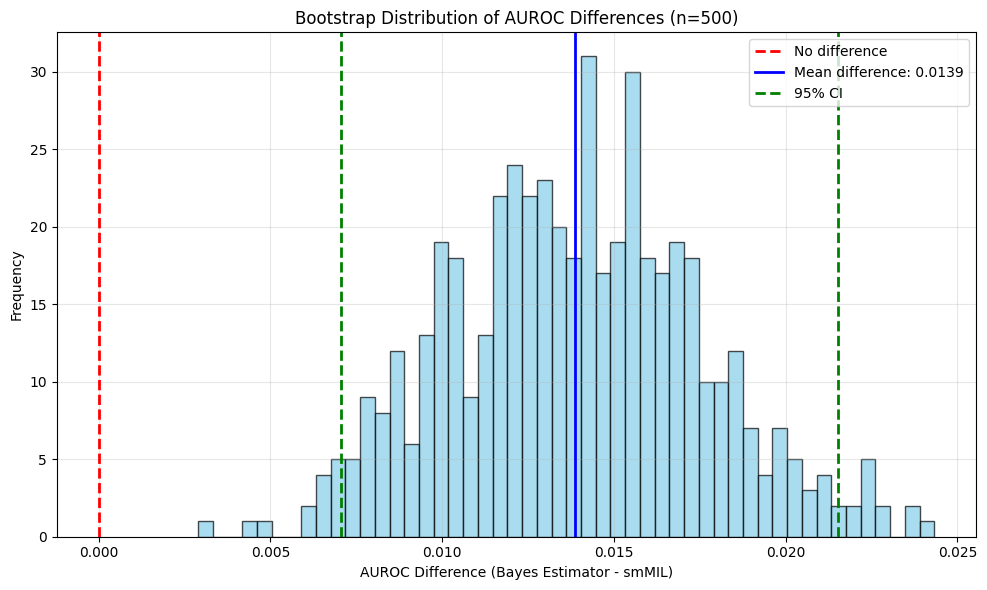

Difference: 0.0139
95% CI: [0.0070, 0.0215]
P-value: 0.0000


In [14]:
import torch
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt

def paired_bootstrap_test(y_true, y_pred1, y_pred2, n_bootstrap=500, alpha=0.05, 
                          label1="Bayes Estimator", label2="smAP", plot=True, seed=42):
    
    # Set random seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    n_samples = len(y_true)
    differences = []
    
    # Original difference - create fresh metric instances
    auroc1_orig = torchmetrics.AUROC(task="binary")
    auroc2_orig = torchmetrics.AUROC(task="binary")
    original_diff = (auroc1_orig(y_pred1, y_true) - auroc2_orig(y_pred2, y_true)).item()
    
    for _ in range(n_bootstrap):
        # Resample indices with replacement (using torch)
        indices = torch.randint(0, n_samples, (n_samples,))
        
        # Calculate metrics on bootstrap sample - create fresh metric instances for each iteration
        auroc1_metric = torchmetrics.AUROC(task="binary")
        auroc2_metric = torchmetrics.AUROC(task="binary")
        auroc1 = auroc1_metric(y_pred1[indices], y_true[indices]).item()
        auroc2 = auroc2_metric(y_pred2[indices], y_true[indices]).item()
        
        differences.append(auroc1 - auroc2)
    
    differences = np.array(differences)
    
    # Calculate confidence interval
    ci_lower = np.percentile(differences, 100 * alpha / 2)
    ci_upper = np.percentile(differences, 100 * (1 - alpha / 2))
    
    # P-value (two-tailed): proportion of bootstrap samples where difference has opposite sign
    p_value = np.mean(differences * original_diff < 0) * 2
    
    results = {
        'original_difference': original_diff,
        'mean_difference': np.mean(differences),
        'std_difference': np.std(differences),
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': min(p_value, 1.0),  # Cap at 1.0
        'significant': ci_lower > 0 or ci_upper < 0
    }
    
    # Plot histogram
    if plot:
        plt.figure(figsize=(10, 6))
        plt.hist(differences, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
        plt.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference')
        plt.axvline(np.mean(differences), color='blue', linestyle='-', linewidth=2, 
                    label=f'Mean difference: {np.mean(differences):.4f}')
        plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label='95% CI')
        plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2)
        
        plt.xlabel(f'AUROC Difference ({label1} - {label2})')
        plt.ylabel('Frequency')
        plt.title(f'Bootstrap Distribution of AUROC Differences (n={n_bootstrap})')
        plt.legend()
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return results

# Example usage
results = paired_bootstrap_test(y_true, bayes_proba, smAP_predictions, 
                                label1="Bayes Estimator", label2="smMIL", seed=2)
print(f"Difference: {results['original_difference']:.4f}")
print(f"95% CI: [{results['ci_lower']:.4f}, {results['ci_upper']:.4f}]")
print(f"P-value: {results['p_value']:.4f}")